In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np

In [5]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## EDA

In [6]:
# ==========================================
# 1. DATA LOADING & INSPECTION
# ==========================================

df = pd.read_csv("indonesian_chat.csv")
df.head()

,id,chat,label
0,1,main mu kek tai cok,violence
1,2,user telat ngasih tau elu edan sarap gue berga...,violence
2,3,kadang berfikir percaya tuhan jatuh berkalikal...,neutral
3,4,user user aku\n\nku tau matamu sipit diliat,racist
4,5,capek deh ketemu kaum cina kapir gini match,racist


In [7]:
print(f"\nTotal Observations: {df.shape[0]}")
print(f"Columns: {list(df.columns)}")
print("\nSample Data:")
print(df.head())


Total Observations: 10702
Columns: ['id', 'chat', 'label']

Sample Data:
   id                                               chat     label
0   1                                main mu kek tai cok  violence
1   2  user telat ngasih tau elu edan sarap gue berga...  violence
2   3  kadang berfikir percaya tuhan jatuh berkalikal...   neutral
3   4        user user aku\n\nku tau matamu sipit diliat    racist
4   5        capek deh ketemu kaum cina kapir gini match    racist


In [8]:
df.dropna(subset=['chat', 'label'], inplace=True)

In [9]:
# ==========================================
# 2. LABEL DISTRIBUTION ANALYSIS
# ==========================================
print("\n--- Analyzing Label Distribution ---")
label_counts = df['label'].value_counts()
print(label_counts)


--- Analyzing Label Distribution ---
label
violence      2983
neutral       2729
racist        2506
harassment    2484
Name: count, dtype: int64


/tmp/ipython-input-2880319986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, order=label_counts.index, palette='viridis')


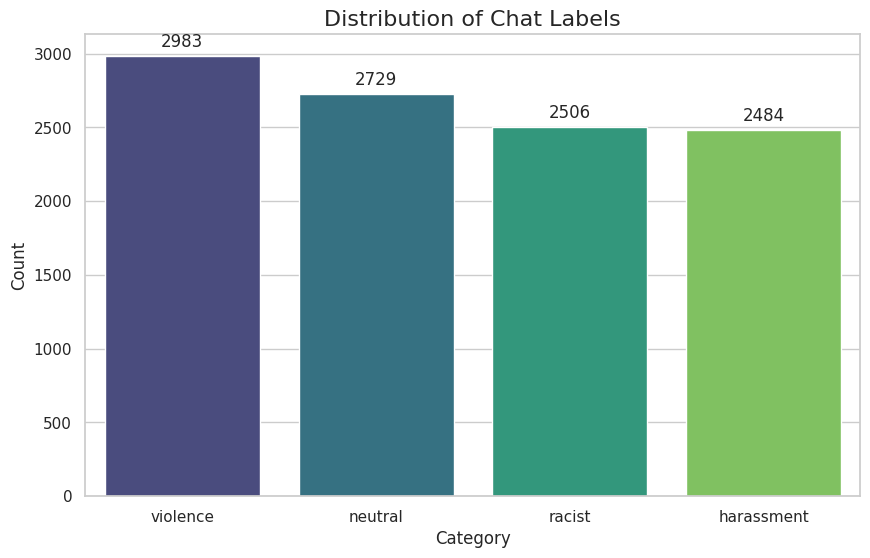

In [10]:
# Visualisasi Bar Chart untuk Distribusi Label
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=df, order=label_counts.index, palette='viridis')
plt.title('Distribution of Chat Labels', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')
plt.show()

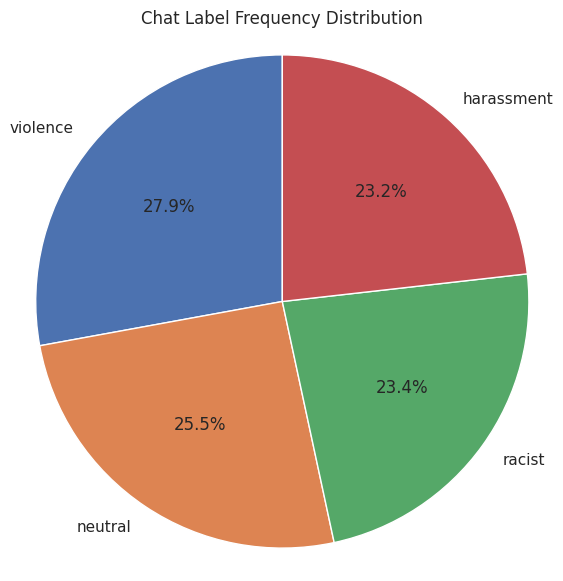

In [11]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(label_counts,
        labels=label_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Chat Label Frequency Distribution')
plt.axis('equal')
plt.show()

In [12]:
# ==========================================
# 3. TEXT CHARACTERISTICS (MESSAGE LENGTH)
# ==========================================
df['word_count'] = df['chat'].apply(lambda x: len(str(x).split()))
print(df.groupby('label')['word_count'].describe())

             count       mean       std  min  25%   50%   75%   max
label                                                              
harassment  2484.0   9.066828  5.163493  1.0  5.0   8.0  12.0  47.0
neutral     2729.0  13.283254  7.698737  1.0  7.0  12.0  18.0  42.0
racist      2506.0  10.072626  5.500890  2.0  6.0   9.0  12.0  46.0
violence    2983.0   8.683205  5.673950  1.0  5.0   7.0  10.0  39.0


/tmp/ipython-input-3480368288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='word_count', data=df, palette='coolwarm')


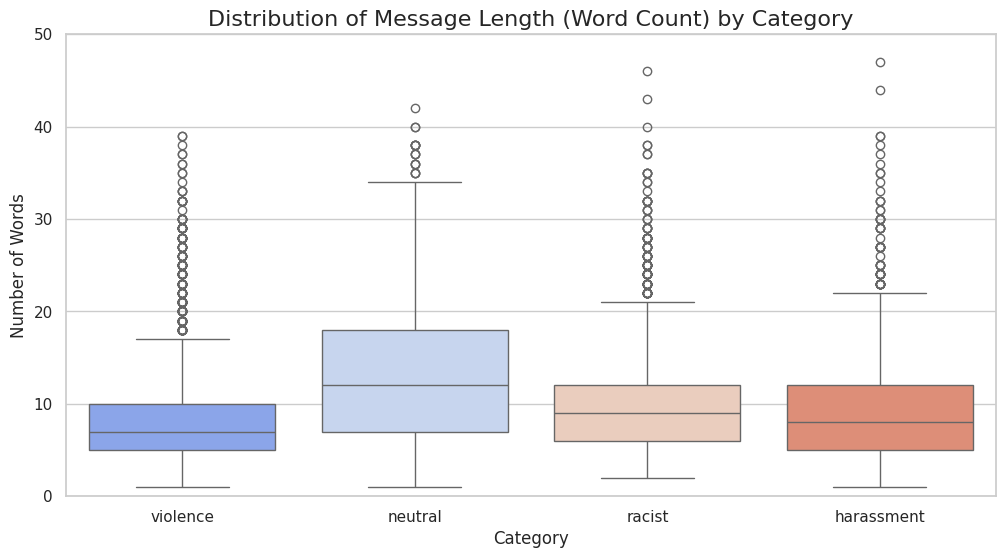

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='word_count', data=df, palette='coolwarm')
plt.title('Distribution of Message Length (Word Count) by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Number of Words')
plt.ylim(0, 50)
plt.show()

In [14]:
# ==========================================
# 4. VOCABULARY ANALYSIS (WORD CLOUDS)
# ==========================================

def generate_wordcloud(text, title):
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap='inferno',
                   max_words=200).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

Generating Word Cloud for: neutral


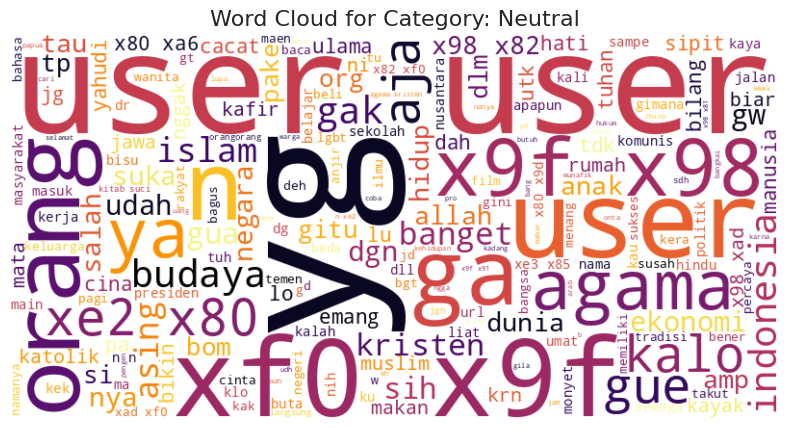

Generating Word Cloud for: violence


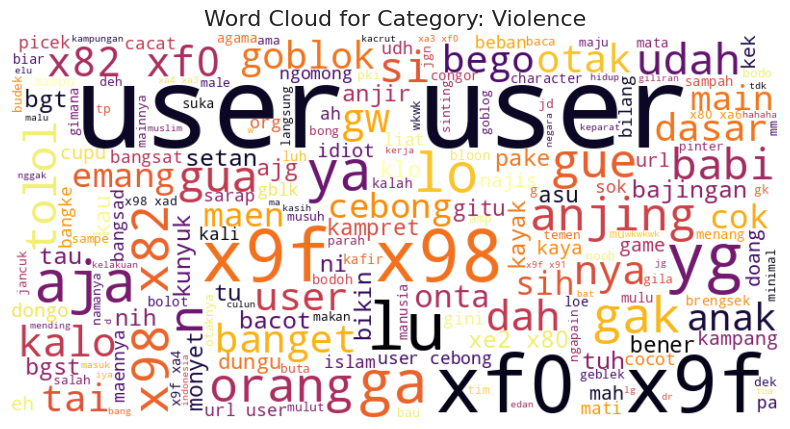

Generating Word Cloud for: racist


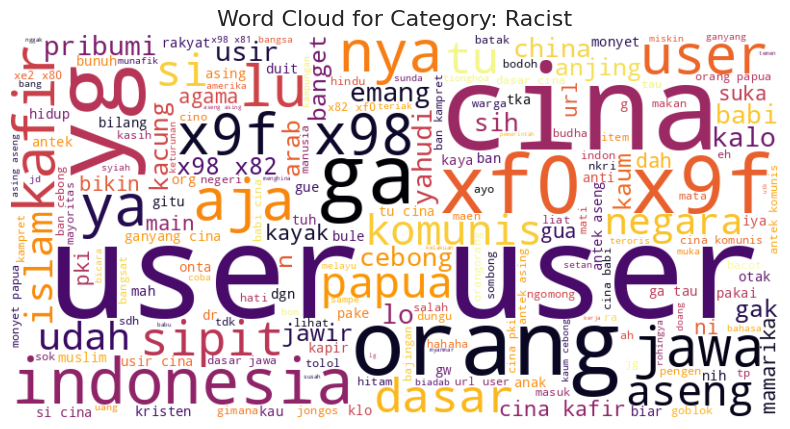

Generating Word Cloud for: harassment


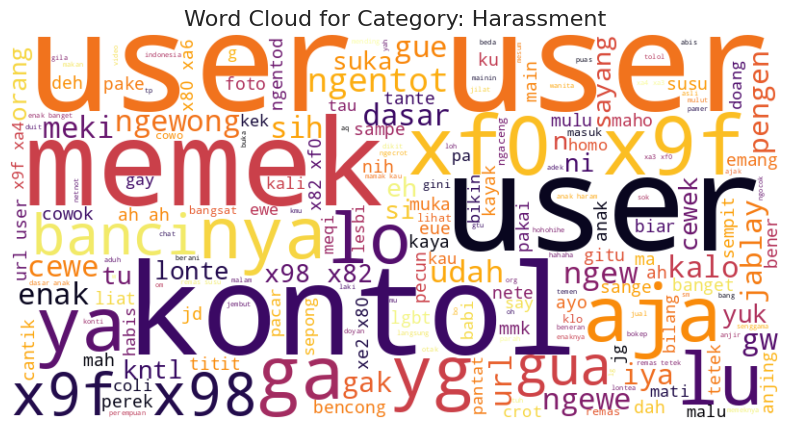

In [15]:
categories = ['neutral', 'violence', 'racist', 'harassment']

for cat in categories:
    subset_text = " ".join(text for text in df[df['label'] == cat]['chat'].astype(str))

    print(f"Generating Word Cloud for: {cat}")
    generate_wordcloud(subset_text, f'Word Cloud for Category: {cat.capitalize()}')

## Data Splitting

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X = df['chat']
y = df['label']

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [19]:
total_len = len(df)
print(f"Total Data: {total_len}")
print(f"Training Set   : {len(X_train)}")
print(f"Validation Set : {len(X_val)}")
print(f"Testing Set    : {len(X_test)}")

Total Data: 10702
Training Set   : 8561
Validation Set : 1070
Testing Set    : 1071


In [20]:
def print_dist(y_subset, name):
    dist = y_subset.value_counts(normalize=True) * 100
    print(f"\n{name} Distribution (%):")
    print(dist.round(2))

print_dist(y, "Original Data")
print_dist(y_train, "Training Set")
print_dist(y_val, "Validation Set")
print_dist(y_test, "Testing Set")


Original Data Distribution (%):
label
violence      27.87
neutral       25.50
racist        23.42
harassment    23.21
Name: proportion, dtype: float64

Training Set Distribution (%):
label
violence      27.87
neutral       25.50
racist        23.42
harassment    23.21
Name: proportion, dtype: float64

Validation Set Distribution (%):
label
violence      27.85
neutral       25.51
racist        23.36
harassment    23.27
Name: proportion, dtype: float64

Testing Set Distribution (%):
label
violence      27.92
neutral       25.49
racist        23.44
harassment    23.16
Name: proportion, dtype: float64


# IndoBert

## Data PreProcessing

In [21]:
import re
import string

In [22]:
# ==========================================
# 1. DEFINE DICTIONARIES & MAPPINGS
# ==========================================

# Dictionary untuk "Leet Speak" / Alay (Angka ke Huruf)
leet_dict = {
    '4': 'a',
    '1': 'i',
    '3': 'e',
    '0': 'o',
    '5': 's',
    '6': 'g',
    '8': 'b',
    '7': 't',
    '@': 'a'
}

In [23]:
# Dictionary Slang
url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
df_slang = pd.read_csv(url)
slang_dict = dict(zip(df_slang['slang'], df_slang['formal']))

game_slang_additions = {
    # Istilah Game & Kasar Spesifik
    'noob': 'pemula',
    'nub': 'pemula',
    'cupu': 'lemah',
    'ez': 'mudah',
    'easy': 'mudah',
    'afk': 'diam',
    'dc': 'putus koneksi',
    'lag': 'lambat',
    'ngeframe': 'lambat',
    'turu': 'tidur',
    'by1': 'duel',
    'by one': 'duel',
    'jancok': 'bangsat',
    'cok': 'bangsat',
    'coeg': 'bangsat',
    'njir': 'anjing',
    'anj': 'anjing',
    'asu': 'anjing',
    'bgst': 'bangsat',
    'kntl': 'kelamin',
    'memek': 'kelamin',
    'kontol': 'kelamin',
    'bego': 'bodoh',
    'goblok': 'bodoh',
    'tolol': 'bodoh',
    'gk': 'tidak',
    'ga': 'tidak',
    'gak': 'tidak',
    'nggak': 'tidak',
    'bgt': 'banget',
    'dr': 'dari',
    'kpn': 'kapan',
    'knp': 'kenapa',
    'bapuk': 'jelek',
    'burig': 'burik',
    'ep ep': 'free fire',
}

slang_dict.update(game_slang_additions)

In [24]:
# ==========================================
# 2. PREPROCESSING FUNCTIONS
# ==========================================

def normalize_leet(text):
    """
    Mengubah angka yang menyerupai huruf kembali menjadi huruf (4nj1ng -> anjing).
    Note: Angka '2' seringkali berarti perulangan (makan2 -> makan-makan),
    jadi tidak dimasukkan ke leet_dict di atas agar tidak merusak makna reduplikasi.
    """
    for char, replacement in leet_dict.items():
        text = text.replace(char, replacement)
    return text

In [25]:
def normalize_slang(text):
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

In [26]:
def clean_text(text):
    # 1. Lowercasing (untuk uncased models)
    text = str(text).lower()

    # 2. Hapus Byte Code / Emoji aneh (\xf0\x9f...)
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 3. Leet Speak Normalization (Recover intended lexical meaning)
    text = normalize_leet(text)

    # 4. Slang Normalization (Selective mapping)
    text = normalize_slang(text)

    # 5. Whitespace Adjustment (Menghapus spasi berlebih/double space)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [27]:
# ==========================================
# 3. APPLY TO DATASET
# ==========================================

df_clean = df.copy()

df_clean['chat_clean'] = df_clean['chat'].apply(clean_text)

In [28]:
# ==========================================
# 4. INSPECTION (BEFORE VS AFTER)
# ==========================================
print("\n--- Preprocessing Results (Sample) ---")
pd.set_option('display.max_colwidth', 100)
print(df_clean[['chat', 'chat_clean']].head(10))


--- Preprocessing Results (Sample) ---
                                                                                                  chat  \
0                                                                                  main mu kek tai cok   
1                                                 user telat ngasih tau elu edan sarap gue bergaul elu   
2  kadang berfikir percaya tuhan jatuh berkalikali kadang tuhan ninggalkan orangtuaku berencana ber...   
3                                                          user user aku\n\nku tau matamu sipit diliat   
4                                                          capek deh ketemu kaum cina kapir gini match   
5                                                                        skill cacad ngide jungler cok   
6                                                                                 gg main lo keren bro   
7  gue aja kelar rewatch aldnoah zero kampret emang endingnya 2 karakter utama cowonya kena friendz...   
8  adm

In [29]:
# Cek contoh spesifik leet speak
print("--- Testing Specific Leet Speak Cases ---")
test_cases = ["dasar lu 4nj1ng", "b0d0h banget", "k4mpret l0e", "m4t1 aja"]
for t in test_cases:
    print(f"Original: {t} -> Cleaned: {clean_text(t)}")

--- Testing Specific Leet Speak Cases ---
Original: dasar lu 4nj1ng -> Cleaned: dasar lu anjing
Original: b0d0h banget -> Cleaned: bodoh banget
Original: k4mpret l0e -> Cleaned: kampret lo
Original: m4t1 aja -> Cleaned: mati saja


## Model Selection

In [30]:
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.metrics import classification_report, accuracy_score, f1_score
import torch
from tqdm.notebook import tqdm

In [31]:
df_train = pd.DataFrame({'chat_clean': X_train, 'label': y_train}).reset_index(drop=True)
df_val = pd.DataFrame({'chat_clean': X_val, 'label': y_val}).reset_index(drop=True)
df_test = pd.DataFrame({'chat_clean': X_test, 'label': y_test}).reset_index(drop=True)

In [32]:
# ==========================================
# 1. LABEL ENCODING
# ==========================================
le = LabelEncoder()
y_train_encoded = le.fit_transform(df_train['label'])
y_val_encoded = le.transform(df_val['label'])
y_test_encoded = le.transform(df_test['label'])

In [33]:
id2label = {id_: label for id_, label in enumerate(le.classes_)}
num_labels = len(le.classes_)
print(f"Total Labels: {num_labels} -> {id2label}")

Total Labels: 4 -> {0: 'harassment', 1: 'neutral', 2: 'racist', 3: 'violence'}


In [34]:
# Cek ketersediaan GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print('There are %d GPU(s) available.' % torch.cuda.device_count())
    print('We will use the GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4


In [35]:
# ==========================================
# 2. DEFINISI MODEL DAN HYPERPARAMETERS
# ==========================================
MODEL_VARIANTS = {
    # "IndoBERT Base (cased)": "indobenchmark/indobert-base-p1",
    # "IndoBERT Base (uncased)": "indolem/indobert-base-uncased",
    "IndoBERTweet (uncased)": "indolem/indobertweet-base-uncased"
}

BATCH_SIZE = 16
EPOCHS = 3
MAX_LEN = 128

In [36]:
# ==========================================
# 3. FUNGSI UTAMA: PREPARE DATA, TRAIN, EVALUATE
# ==========================================

def prepare_data_loader(tokenizer, texts, labels, batch_size, is_train=True):
    # Tokenisasi
    encoded_data = tokenizer.batch_encode_plus(
        texts.tolist(),
        add_special_tokens=True,
        return_attention_mask=True,
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

    input_ids = encoded_data['input_ids']
    attention_masks = encoded_data['attention_mask']
    labels = torch.tensor(labels)

    dataset = TensorDataset(input_ids, attention_masks, labels)

    if is_train:
        sampler = RandomSampler(dataset)
    else:
        sampler = SequentialSampler(dataset)

    dataloader = DataLoader(dataset, sampler=sampler, batch_size=batch_size)
    return dataloader

In [37]:
def train_and_evaluate_model(model_name, model_path):
    print(f"--- Training and Evaluating: {model_name} ---")

    # Inisialisasi Tokenizer dan Model
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=num_labels,
        id2label=id2label
    )
    model.to(device)

    # Persiapan DataLoader
    train_dataloader = prepare_data_loader(tokenizer, df_train['chat_clean'], y_train_encoded, BATCH_SIZE, is_train=True)
    val_dataloader = prepare_data_loader(tokenizer, df_val['chat_clean'], y_val_encoded, BATCH_SIZE, is_train=False)

    # Optimizer dan Scheduler
    optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
    total_steps = len(train_dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    best_val_f1 = -1

    # --- TRAINING LOOP ---
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        model.train()
        total_loss = 0

        for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_input_mask, b_labels = batch

            model.zero_grad()

            outputs = model(b_input_ids,
                            token_type_ids=None,
                            attention_mask=b_input_mask,
                            labels=b_labels)

            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_loss / len(train_dataloader)
        print(f"  Average Training Loss: {avg_train_loss:.4f}")

        # --- VALIDATION/EVALUATION ---
        model.eval()
        val_preds = []
        val_true = []

        for batch in tqdm(val_dataloader, desc="Validation"):
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_input_mask, b_labels = batch

            with torch.no_grad():
                outputs = model(b_input_ids,
                                token_type_ids=None,
                                attention_mask=b_input_mask)

            logits = outputs.logits
            logits = logits.detach().cpu().numpy()
            label_ids = b_labels.to('cpu').numpy()

            val_preds.extend(np.argmax(logits, axis=1).flatten())
            val_true.extend(label_ids.flatten())

        val_f1 = f1_score(val_true, val_preds, average='weighted')
        print(f"  Validation Weighted F1 Score: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f'best_model_checkpoint_{model_name.replace(" ", "_")}.pt')
            print(f"  --> New best model saved with F1: {best_val_f1:.4f}")

    # --- FINAL TEST EVALUATION (menggunakan model terbaik) ---
    print(f"\n--- Testing Best {model_name} Model ---")
    model.load_state_dict(torch.load(f'best_model_checkpoint_{model_name.replace(" ", "_")}.pt'))
    test_dataloader = prepare_data_loader(tokenizer, df_test['chat_clean'], y_test_encoded, BATCH_SIZE, is_train=False)

    model.eval()
    test_preds = []
    test_true = []

    for batch in tqdm(test_dataloader, desc="Testing"):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

        logits = outputs.logits
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        test_preds.extend(np.argmax(logits, axis=1).flatten())
        test_true.extend(label_ids.flatten())

    # Laporan Klasifikasi
    report = classification_report(test_true, test_preds, target_names=le.classes_, digits=4)
    test_f1 = f1_score(test_true, test_preds, average='weighted')

    print("\n[ Final Test Classification Report ]")
    print(report)
    print(f"Final Test Weighted F1 Score: {test_f1:.4f}")

    return {
        'model_name': model_name,
        'test_weighted_f1': test_f1,
        'report': report
    }

In [38]:
# ==========================================
# 4. RUN ALL VARIANTS & COMPARE
# ==========================================
all_results = []

for name, path in MODEL_VARIANTS.items():
    result = train_and_evaluate_model(name, path)
    all_results.append(result)

# Menampilkan perbandingan hasil
print("\n" + "="*50)
print("              SUMMARY OF INDOBERT VARIANTS")
print("="*50)

# Buat DataFrame untuk hasil ringkasan
summary_df = pd.DataFrame([
    {'Model': r['model_name'], 'Test Weighted F1': r['test_weighted_f1']}
    for r in all_results
])

print(summary_df.sort_values(by='Test Weighted F1', ascending=False))
print("="*50)

--- Training and Evaluating: IndoBERTweet (uncased) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  Average Training Loss: 0.2113


Validation:   0%|          | 0/67 [00:00<?, ?it/s]

  Validation Weighted F1 Score: 0.8621
  --> New best model saved with F1: 0.8621

--- Testing Best IndoBERTweet (uncased) Model ---


Testing:   0%|          | 0/67 [00:00<?, ?it/s]


[ Final Test Classification Report ]
              precision    recall  f1-score   support

  harassment     0.8846    0.9274    0.9055       248
     neutral     0.8494    0.8059    0.8271       273
      racist     0.8880    0.8845    0.8862       251
    violence     0.8311    0.8395    0.8353       299

    accuracy                         0.8618      1071
   macro avg     0.8633    0.8643    0.8635      1071
weighted avg     0.8615    0.8618    0.8614      1071

Final Test Weighted F1 Score: 0.8614

              SUMMARY OF INDOBERT VARIANTS
                    Model  Test Weighted F1
0  IndoBERTweet (uncased)          0.861388


## Model Hyperparameter Tuning

In [39]:
import copy
import torch
from torch.nn import CrossEntropyLoss
import itertools
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report, f1_score
from tqdm.notebook import tqdm

In [40]:
# ==========================================
# 1. KONFIGURASI HYPERPARAMETER GRID
# ==========================================
PARAM_GRID = {
    'learning_rate': [2e-5, 3e-5, 5e-5],
    'batch_size': [16, 32],
    'epochs': [4]
}

PATIENCE = 2
MAX_LEN = 128
MODEL_VARIANTS = {
    # "IndoBERT Base (cased)": "indobenchmark/indobert-base-p1",
    # "IndoBERT Base (uncased)": "indolem/indobert-base-uncased",
    "IndoBERTweet (uncased)": "indolem/indobertweet-base-uncased"
}

In [41]:
# ==========================================
# 2. CLASS: EARLY STOPPING
# ==========================================
class EarlyStopping:
    def __init__(self, patience=2, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0

In [42]:
# ==========================================
# 3. FUNGSI TRAINING SATU SESI
# ==========================================
def train_model_session(model, train_loader, val_loader, optimizer, scheduler, epochs, device):
    early_stopper = EarlyStopping(patience=PATIENCE)
    best_val_f1 = 0.0

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss = 0
        for batch in train_loader:
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_input_mask, b_labels = batch

            model.zero_grad()
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
            loss = outputs.loss
            train_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        # --- Validation ---
        model.eval()
        val_loss = 0
        val_preds, val_true = [], []

        for batch in val_loader:
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_input_mask, b_labels = batch

            with torch.no_grad():
                outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

            val_loss += outputs.loss.item()
            logits = outputs.logits.detach().cpu().numpy()
            label_ids = b_labels.to('cpu').numpy()
            val_preds.extend(np.argmax(logits, axis=1).flatten())
            val_true.extend(label_ids.flatten())

        avg_val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(val_true, val_preds, average='weighted')

        # Simpan F1 terbaik sesi ini
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1

        # Cek Early Stopping
        early_stopper(avg_val_loss, model)
        if early_stopper.early_stop:
            break

    return early_stopper.best_model_state, best_val_f1

In [43]:
# ==========================================
# 4. FUNGSI UTAMA: HYPERPARAMETER TUNING
# ==========================================
def run_hyperparameter_tuning(model_name, model_id):
    print(f"\n{'='*60}")
    print(f"TUNING MODEL: {model_name}")
    print(f"Source: {model_id}")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    # Generate semua kombinasi hyperparameter
    keys, values = zip(*PARAM_GRID.items())
    param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    best_overall_f1 = -1
    best_overall_params = None
    best_overall_state = None

    # --- GRID SEARCH LOOP ---
    print(f"Total Combinations to Try: {len(param_combinations)}")

    for i, params in enumerate(param_combinations):
        lr = params['learning_rate']
        bs = params['batch_size']
        ep = params['epochs']

        print(f"\n[{i+1}/{len(param_combinations)}] Params: LR={lr}, Batch={bs}")

        # Prepare DataLoaders dengan Batch Size dinamis
        train_loader = prepare_data_loader(tokenizer, df_train['chat_clean'], y_train_encoded, bs, is_train=True)
        val_loader = prepare_data_loader(tokenizer, df_val['chat_clean'], y_val_encoded, bs, is_train=False)

        # Init Model Baru
        model = AutoModelForSequenceClassification.from_pretrained(
            model_id, num_labels=4, id2label=id2label, label2id={v: k for k, v in id2label.items()}
        )
        model.to(device)

        # Optimizer & Scheduler
        optimizer = AdamW(model.parameters(), lr=lr)
        total_steps = len(train_loader) * ep
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

        # Train Session
        best_state, val_f1 = train_model_session(model, train_loader, val_loader, optimizer, scheduler, ep, device)

        print(f"   -> Result Validation F1: {val_f1:.4f}")

        # Update Global Best
        if val_f1 > best_overall_f1:
            best_overall_f1 = val_f1
            best_overall_params = params
            best_overall_state = best_state
            print("   -> NEW BEST PARAMETERS FOUND!")

    # --- FINAL EVALUATION ON TEST SET (Using Best Params) ---
    print(f"\n{'-'*40}")
    print(f"BEST PARAMS for {model_name}: {best_overall_params}")
    print(f"Best Validation F1: {best_overall_f1:.4f}")
    print(f"{'-'*40}")

    # Load state terbaik ke model
    final_model = AutoModelForSequenceClassification.from_pretrained(
        model_id, num_labels=4, id2label=id2label, label2id={v: k for k, v in id2label.items()}
    )
    final_model.load_state_dict(best_overall_state)
    final_model.to(device)

    # Save Model
    save_path = f"best_model_{model_name.replace(' ', '_')}.pt"
    torch.save(final_model.state_dict(), save_path)
    print(f"Best model saved to {save_path}")

    # Test Prediction (Gunakan batch size dari best params)
    final_bs = best_overall_params['batch_size']
    test_loader = prepare_data_loader(tokenizer, df_test['chat_clean'], y_test_encoded, final_bs, is_train=False)

    final_model.eval()
    test_preds, test_true = [], []
    for batch in test_loader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch
        with torch.no_grad():
            outputs = final_model(b_input_ids, attention_mask=b_input_mask)
        logits = outputs.logits.detach().cpu().numpy()
        test_preds.extend(np.argmax(logits, axis=1).flatten())
        test_true.extend(b_labels.to('cpu').numpy().flatten())

    report = classification_report(test_true, test_preds, target_names=le.classes_, digits=4)
    print(f"\n[FINAL TEST REPORT - {model_name}]")
    print(report)

    return save_path, report, best_overall_params

In [45]:
# ==========================================
# 5. EKSEKUSI TUNING UNTUK SEMUA VARIAN
# ==========================================
final_results_tuning = {}

for name, path in MODEL_VARIANTS.items():
    saved_path, report, best_params = run_hyperparameter_tuning(name, path)
    final_results_tuning[name] = {
        'report': report,
        'best_params': best_params
    }


TUNING MODEL: IndoBERTweet (uncased)
Source: indolem/indobertweet-base-uncased
Total Combinations to Try: 6

[1/6] Params: LR=2e-05, Batch=16


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   -> Result Validation F1: 0.8696
   -> NEW BEST PARAMETERS FOUND!

[2/6] Params: LR=2e-05, Batch=32


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   -> Result Validation F1: 0.8549

[3/6] Params: LR=3e-05, Batch=16


...

   -> Result Validation F1: 0.8742
   -> NEW BEST PARAMETERS FOUND!

[6/6] Params: LR=5e-05, Batch=32


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   -> Result Validation F1: 0.8701

----------------------------------------
BEST PARAMS for IndoBERTweet (uncased): {'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 4}
Best Validation F1: 0.8742
----------------------------------------


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Best model saved to best_model_IndoBERTweet_(uncased).pt

[FINAL TEST REPORT - IndoBERTweet (uncased)]
              precision    recall  f1-score   support

  harassment     0.9372    0.9032    0.9199       248
     neutral     0.8110    0.8645    0.8369       273
      racist     0.9040    0.9004    0.9022       251
    violence     0.8660    0.8428    0.8542       299

    accuracy                         0.8758      1071
   macro avg     0.8796    0.8777    0.8783      1071
weighted avg     0.8774    0.8758    0.8763      1071



In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. AGGREGATE RESULTS
# ==========================================
print("--- INDOBERT MODEL COMPARISON SUMMARY ---")

results_data = []

for model_name, data in final_results_tuning.items():
    report = data['report']

    report_lines = report.split('\n')
    for line in report_lines:
        if 'weighted avg' in line:
            parts = line.split()
            f1 = float(parts[-2])

            results_data.append({
                'Model Variant': model_name,
                'Test F1-Score': f1,
                'Best Params': data['best_params']
            })

comparison_df = pd.DataFrame(results_data)
comparison_df = comparison_df.sort_values(by='Test F1-Score', ascending=False).reset_index(drop=True)

print("\n[ Performance Table ]")
print(comparison_df[['Model Variant', 'Test F1-Score']])

# ==========================================
# 2. SELECT BEST MODEL FOR ENSEMBLE
# ==========================================
best_model_name = comparison_df.iloc[0]['Model Variant']
best_f1 = comparison_df.iloc[0]['Test F1-Score']

print(f"\n{'='*50}")
print(f"WINNING MODEL: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print(f"{'='*50}")

--- INDOBERT MODEL COMPARISON SUMMARY ---

[ Performance Table ]
            Model Variant  Test F1-Score
0  IndoBERTweet (uncased)         0.8763

WINNING MODEL: IndoBERTweet (uncased)
F1-Score: 0.8763


# BiLSTM + FastText Embeddings

## Data Preprocessing

In [47]:
!pip install Sastrawi gensim tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.4 MB/s eta 0:00:00


In [48]:
import re
import numpy as np
import pandas as pd
import pickle
import tensorflow as tf
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from gensim.models import FastText
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
from tqdm.notebook import tqdm

In [49]:
# ==========================================
# LABEL ENCODING
# ==========================================
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Menggunakan y_train, y_val, y_test dari code Anda
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

print(f"   Classes: {le.classes_}")

   Classes: ['harassment' 'neutral' 'racist' 'violence']


In [50]:
# ==========================================
# PREPROCESSING
# ==========================================

# A. Slang Dictionary
slang_dict_bilstm = {
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "ngga": "tidak",
    "tdk": "tidak", "tak": "tidak",
    "gue": "saya", "gua": "saya", "gw": "saya",
    "lu": "kamu", "loe": "kamu", "elo": "kamu", "km": "kamu",
    "pengen": "ingin", "pingin": "ingin", "ngerti": "mengerti",
    "ngomong": "bicara", "bilang": "kata", "bikin": "buat",
    "liat": "lihat", "denger": "dengar",
    "bgt": "banget", "bangettt": "banget", "parah": "sangat",
    "btw": "by the way", "wkwk": "tertawa", "wk": "tertawa", "haha": "tertawa",
    "yg": "yang", "aja": "saja", "doang": "saja", "kok": "mengapa",
    "gimana": "bagaimana", "kalo": "kalau"
}

In [51]:
# B. Stopwords & Stemmer
stop_factory = StopWordRemoverFactory()
stopwords_list = set(stop_factory.get_stop_words())

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [52]:
# C. Fungsi Cleaning
def chat_cleaning_bilstm(chat):
    chat = str(chat).lower()
    chat = re.sub(r"http\S+|www\.\S+", "", chat)
    chat = re.sub(r"[^a-z\s]", " ", chat)
    chat = re.sub(r"\s+", " ", chat).strip()
    chat = chat.encode('ascii', 'ignore').decode('ascii')
    return chat

def tokenize(chat):
    return chat.split()

def normalize_slang(tokens):
    return [slang_dict_bilstm[t] if t in slang_dict_bilstm else t for t in tokens]

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stopwords_list]

def stemming_process(tokens):
    return [stemmer.stem(t) for t in tokens]

def preprocess_chat_final(chat):
    cleaned = chat_cleaning_bilstm(chat)
    tokens = tokenize(cleaned)
    tokens = normalize_slang(tokens)
    tokens = remove_stopwords(tokens)
    tokens = stemming_process(tokens)
    return tokens

In [53]:
# ==========================================
# APPLY PREPROCESSING KE DATASET
# ==========================================

tqdm.pandas()

X_train_tokens = X_train.progress_apply(preprocess_chat_final)
X_val_tokens = X_val.progress_apply(preprocess_chat_final)
X_test_tokens = X_test.progress_apply(preprocess_chat_final)

  0%|          | 0/8561 [00:00<?, ?it/s]

  0%|          | 0/1070 [00:00<?, ?it/s]

  0%|          | 0/1071 [00:00<?, ?it/s]

## Embedding

In [54]:
# ==========================================
# FASTTEXT & EMBEDDING
# ==========================================
fasttext_model = FastText(
    sentences=X_train_tokens,
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

In [55]:
# Tokenizer
tokenizer_bilstm = Tokenizer()
tokenizer_bilstm.fit_on_texts(X_train_tokens)

In [56]:
# Sequencing
X_train_seq = tokenizer_bilstm.texts_to_sequences(X_train_tokens)
X_val_seq = tokenizer_bilstm.texts_to_sequences(X_val_tokens)
X_test_seq = tokenizer_bilstm.texts_to_sequences(X_test_tokens)

In [57]:
# Padding
maxlen = 50
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_val_pad = pad_sequences(X_val_seq, maxlen=maxlen)
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)

In [58]:
# Embedding Matrix
word_index = tokenizer_bilstm.word_index
vocab_size = len(word_index) + 1
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if word in fasttext_model.wv:
        embedding_matrix[i] = fasttext_model.wv[word]

print(f"Vocab Size: {vocab_size}")
print(f"Embedding Matrix Shape: {embedding_matrix.shape}")

Vocab Size: 13859
Embedding Matrix Shape: (13859, 300)


## Base Model BiLSTM

In [59]:
# ==========================================
# BASE MODEL
# ==========================================

# Definisi Arsitektur Base Model (Sesuai snippet kamu)
base_model = Sequential([
    Input(shape=(maxlen,)), # Menggunakan maxlen dari preprocessing (50)
    Embedding(
        input_dim=vocab_size,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=True # Di snippet asli ini True (ikut ditraining ulang)
    ),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

base_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 300)        │     4,157,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,613,704 (17.60 MB)

 Trainable params: 4,613,704 (17.60 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# Training Base Model
es_base = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_base = base_model.fit(
    X_train_pad, y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=20,
    batch_size=32,
    callbacks=[es_base],
    verbose=1
)

Epoch 1/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5180 - loss: 1.1011 - val_accuracy: 0.7645 - val_loss: 0.6427
Epoch 2/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8515 - loss: 0.4539 - val_accuracy: 0.7888 - val_loss: 0.6140
Epoch 3/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9235 - loss: 0.2429 - val_accuracy: 0.7935 - val_loss: 0.6652
Epoch 4/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9618 - loss: 0.1321 - val_accuracy: 0.8056 - val_loss: 0.7692
Epoch 5/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9773 - loss: 0.0780 - val_accuracy: 0.7963 - val_loss: 0.8067


In [61]:
# Evaluasi Base Model
print("\n--- Evaluation Base Model ---")
y_pred_prob_base = base_model.predict(X_test_pad)
y_pred_base = np.argmax(y_pred_prob_base, axis=1)

f1_base = f1_score(y_test_encoded, y_pred_base, average='weighted')
print(f"Base Model F1-Score: {f1_base:.4f}")
print(classification_report(y_test_encoded, y_pred_base, target_names=le.classes_))

# Simpan Base Model ke .keras
base_model.save("base_model_bilstm.keras")


--- Evaluation Base Model ---
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Base Model F1-Score: 0.8086
              precision    recall  f1-score   support

  harassment       0.91      0.82      0.87       248
     neutral       0.76      0.71      0.74       273
      racist       0.89      0.81      0.85       251
    violence       0.72      0.88      0.79       299

    accuracy                           0.81      1071
   macro avg       0.82      0.81      0.81      1071
weighted avg       0.82      0.81      0.81      1071



## Model Hyperparameter Tuning

In [62]:
def build_bilstm_model(lstm_units, dropout_rate, learning_rate):
    model = Sequential([
        Input(shape=(maxlen,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=False
        ),
        Bidirectional(LSTM(lstm_units)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(len(le.classes_), activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [63]:
param_grid = {
    'lstm_units': [128, 256],
    'dropout_rate': [0.3, 0.4],
    'learning_rate': [1e-3],
    'batch_size': [32]
}

early_stop_tuning = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

best_f1_tuned = 0
best_params = {}
tuned_model_path = "best_model_bilstm_tuned.keras"

In [64]:
# Loop Grid Search
for units in param_grid['lstm_units']:
    for dropout in param_grid['dropout_rate']:
        for lr in param_grid['learning_rate']:
            for batch in param_grid['batch_size']:

                print(f"   > Training: Units={units}, Dropout={dropout}, LR={lr}, Batch={batch}")

                model = build_bilstm_model(units, dropout, lr)

                model.fit(
                    X_train_pad, y_train_encoded,
                    validation_data=(X_val_pad, y_val_encoded),
                    epochs=15,
                    batch_size=batch,
                    callbacks=[early_stop_tuning],
                    verbose=0
                )

                # Evaluasi di Validation Set (bukan Test Set dulu)
                y_pred_prob = model.predict(X_val_pad, verbose=0)
                y_pred = np.argmax(y_pred_prob, axis=1)

                current_f1 = f1_score(y_val_encoded, y_pred, average='weighted')
                print(f"     Result Val F1: {current_f1:.4f}")

                # Update Best Model
                if current_f1 > best_f1_tuned:
                    best_f1_tuned = current_f1
                    best_params = {
                        'lstm_units': units,
                        'dropout_rate': dropout,
                        'learning_rate': lr,
                        'batch_size': batch
                    }
                    model.save(tuned_model_path)
                    print("     [NEW BEST TUNED MODEL SAVED!]")


print(f"\n{'-'*40}")
print(f"TUNING COMPLETE.")
print(f"Best Params: {best_params}")
print(f"Best Val F1: {best_f1_tuned:.4f}")
print(f"{'-'*40}")

   > Training: Units=128, Dropout=0.3, LR=0.001, Batch=32
     Result Val F1: 0.6409
     [NEW BEST TUNED MODEL SAVED!]
   > Training: Units=128, Dropout=0.4, LR=0.001, Batch=32
     Result Val F1: 0.6381
   > Training: Units=256, Dropout=0.3, LR=0.001, Batch=32
     Result Val F1: 0.6428
     [NEW BEST TUNED MODEL SAVED!]
   > Training: Units=256, Dropout=0.4, LR=0.001, Batch=32
     Result Val F1: 0.6471
     [NEW BEST TUNED MODEL SAVED!]

----------------------------------------
TUNING COMPLETE.
Best Params: {'lstm_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 32}
Best Val F1: 0.6471
----------------------------------------


In [65]:
print(f"\n{'-'*40}")
print(f"TUNING COMPLETE.")
print(f"Best Params: {best_params}")
print(f"Best Val F1: {best_f1_tuned:.4f}")
print(f"{'-'*40}")


----------------------------------------
TUNING COMPLETE.
Best Params: {'lstm_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 32}
Best Val F1: 0.6471
----------------------------------------


In [66]:
# ==========================================
# EVALUASI FINAL
# ==========================================

# Load kembali model tuning terbaik untuk dites di Test Set
from tensorflow.keras.models import load_model
best_tuned_model = load_model(tuned_model_path)
y_pred_prob_tuned = best_tuned_model.predict(X_test_pad)
y_pred_tuned = np.argmax(y_pred_prob_tuned, axis=1)
f1_test_tuned = f1_score(y_test_encoded, y_pred_tuned, average='weighted')

print(f"1. Base Model Test F1  : {f1_base:.4f}")
print(f"2. Tuned Model Test F1 : {f1_test_tuned:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
1. Base Model Test F1  : 0.8086
2. Tuned Model Test F1 : 0.6522


In [67]:
# Logic memilih pemenang
final_model_name = "best_model_bilstm_final.keras" # Nama file final yang akan dipakai ensemble

if f1_test_tuned > f1_base:
    print(f"WINNER: Tuned Model. (Saved as {final_model_name})")
    # Rename/Copy tuned model jadi final
    best_tuned_model.save(final_model_name)
    final_probs = y_pred_prob_tuned
else:
    print(f"WINNER: Base Model. (Saved as {final_model_name})")
    # Rename/Copy base model jadi final
    base_model.save(final_model_name)
    final_probs = y_pred_prob_base

# Simpan probabilitas pemenang untuk Ensemble
np.save("y_pred_prob_bilstm.npy", final_probs)

WINNER: Base Model. (Saved as best_model_bilstm_final.keras)


# Ensemble Method

## Model Selection

In [68]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [69]:
# ==========================================
# 1. GENERATE PROBABILITIES
# ==========================================

# -------------------------
# A. INDOBERT PROBABILITIES
# -------------------------
best_model_name = "IndoBERTweet (uncased)"
if 'model_bert_final' not in locals():
    best_bert_filename = f"best_model_{best_model_name.replace(' ', '_')}.pt"
    best_model_id = MODEL_VARIANTS[best_model_name]

    print(f"Loading IndoBERT: {best_bert_filename}")
    model_bert_final = AutoModelForSequenceClassification.from_pretrained(
        best_model_id, num_labels=4, id2label=id2label, label2id={v: k for k, v in id2label.items()}
    )
    model_bert_final.load_state_dict(torch.load(best_bert_filename))
    model_bert_final.to(device)
    model_bert_final.eval()
    tokenizer_final = AutoTokenizer.from_pretrained(best_model_id)

Loading IndoBERT: best_model_IndoBERTweet_(uncased).pt


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [70]:
def get_bert_probs(df_input, y_input):
    # Menggunakan tokenizer IndoBERT
    loader = prepare_data_loader(tokenizer_final, df_input, y_input, BATCH_SIZE, is_train=False)
    probs_list = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="IndoBERT inference"):
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_input_mask, _ = batch
            outputs = model_bert_final(b_input_ids, attention_mask=b_input_mask)
            probs = F.softmax(outputs.logits, dim=1)
            probs_list.extend(probs.cpu().numpy())
    return np.array(probs_list)

# Menggunakan 'chat_clean' (hasil cleaning IndoBERT)
bert_val_probs = get_bert_probs(df_val['chat_clean'], y_val_encoded)
bert_test_probs = get_bert_probs(df_test['chat_clean'], y_test_encoded)

IndoBERT inference:   0%|          | 0/67 [00:00<?, ?it/s]

IndoBERT inference:   0%|          | 0/67 [00:00<?, ?it/s]

In [71]:
# -------------------------
# B. BILSTM PROBABILITIES (UPDATED)
# -------------------------
try:
    if 'model_bilstm' not in locals():
        model_bilstm = load_model("best_model_bilstm_final.keras")
        print("   - Loaded from disk: best_model_bilstm_final.keras")
    else:
        print("   - Using model_bilstm from memory")
except IOError:
    print("   [ERROR] File 'best_model_bilstm_final.keras' not found!")
    print("   Pastikan Anda sudah menjalankan kode BiLSTM (Opsi A) sebelumnya.")

   - Loaded from disk: best_model_bilstm_final.keras


In [72]:
bilstm_val_probs = model_bilstm.predict(X_val_pad, verbose=0)
bilstm_test_probs = model_bilstm.predict(X_test_pad, verbose=0)

print(f"   - IndoBERT Probs Shape: {bert_test_probs.shape}")
print(f"   - BiLSTM Probs Shape  : {bilstm_test_probs.shape}")

   - IndoBERT Probs Shape: (1071, 4)
   - BiLSTM Probs Shape  : (1071, 4)


## Voting

In [73]:
# ==========================================
# 2. STRATEGI 1: WEIGHTED SOFT VOTING
# ==========================================

val_pred_bert = np.argmax(bert_val_probs, axis=1)
val_pred_bilstm = np.argmax(bilstm_val_probs, axis=1)

f1_val_bert = f1_score(y_val_encoded, val_pred_bert, average='weighted')
f1_val_bilstm = f1_score(y_val_encoded, val_pred_bilstm, average='weighted')

print(f"   Validation F1 IndoBERT: {f1_val_bert:.4f}")
print(f"   Validation F1 BiLSTM  : {f1_val_bilstm:.4f}")

   Validation F1 IndoBERT: 0.8678
   Validation F1 BiLSTM  : 0.7900


In [74]:
# Kalkulasi Bobot
total_f1 = f1_val_bert + f1_val_bilstm
weight_bert = f1_val_bert / total_f1
weight_bilstm = f1_val_bilstm / total_f1

print(f"   Weights -> IndoBERT: {weight_bert:.2f}, BiLSTM: {weight_bilstm:.2f}")

   Weights -> IndoBERT: 0.52, BiLSTM: 0.48


In [75]:
# Aplikasikan ke Test Set
weighted_probs = (bert_test_probs * weight_bert) + (bilstm_test_probs * weight_bilstm)
weighted_voting_preds = np.argmax(weighted_probs, axis=1)

## Stacking

In [76]:
# ==========================================
# 3. STRATEGI 2: STACKING (META LEARNER)
# ==========================================

# Input Features: Gabungan probabilitas dari kedua model
X_meta_train = np.hstack([bert_val_probs, bilstm_val_probs]) # Data Validasi untuk Latih Meta
y_meta_train = y_val_encoded

X_meta_test = np.hstack([bert_test_probs, bilstm_test_probs]) # Data Test untuk Prediksi

In [77]:
# Train Meta-Classifier
meta_model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial', max_iter=200)
meta_model.fit(X_meta_train, y_meta_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial', random_state=42)

In [78]:
# Predict on Test Set
stacking_preds = meta_model.predict(X_meta_test)

## Model Evaluation

In [79]:
# ==========================================
# 4. FINAL COMPARISON & REPORT
# ==========================================
print("\n" + "="*60)
print("FINAL RESULTS COMPARISON")
print("="*60)

# Hitung Metrics F1-Score (Weighted)
scores = {
    "IndoBERT (Solo)": f1_score(y_test_encoded, np.argmax(bert_test_probs, axis=1), average='weighted'),
    "BiLSTM (Solo)": f1_score(y_test_encoded, np.argmax(bilstm_test_probs, axis=1), average='weighted'),
    "Weighted Voting": f1_score(y_test_encoded, weighted_voting_preds, average='weighted'),
    "Stacking (LogReg)": f1_score(y_test_encoded, stacking_preds, average='weighted')
}

# DataFrame Report
results_df = pd.DataFrame(list(scores.items()), columns=['Method', 'Weighted F1-Score'])
results_df = results_df.sort_values(by='Weighted F1-Score', ascending=False)
print(results_df)


FINAL RESULTS COMPARISON
              Method  Weighted F1-Score
3  Stacking (LogReg)           0.879985
0    IndoBERT (Solo)           0.876261
2    Weighted Voting           0.874680
1      BiLSTM (Solo)           0.808619


In [80]:
# --- DETAILED REPORT FOR BEST METHOD ---
best_method_name = results_df.iloc[0]['Method']
print(f"\n[BEST METHOD DETAILED REPORT]: {best_method_name}")

if best_method_name == "Stacking (LogReg)":
    final_preds = stacking_preds
elif best_method_name == "Weighted Voting":
    final_preds = weighted_voting_preds
elif best_method_name == "BiLSTM (Solo)":
    final_preds = np.argmax(bilstm_test_probs, axis=1)
else:
    final_preds = np.argmax(bert_test_probs, axis=1)

print(classification_report(y_test_encoded, final_preds, target_names=le.classes_, digits=4))


[BEST METHOD DETAILED REPORT]: Stacking (LogReg)
              precision    recall  f1-score   support

  harassment     0.9375    0.9073    0.9221       248
     neutral     0.8211    0.8571    0.8387       273
      racist     0.9109    0.8964    0.9036       251
    violence     0.8629    0.8629    0.8629       299

    accuracy                         0.8796      1071
   macro avg     0.8831    0.8809    0.8818      1071
weighted avg     0.8808    0.8796    0.8800      1071



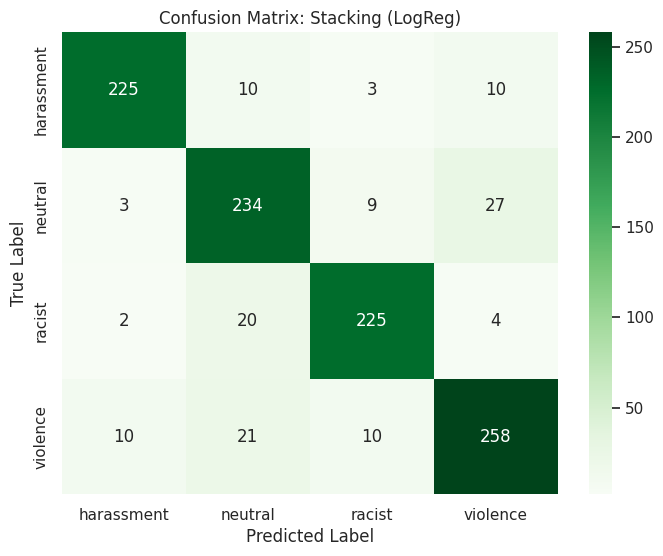

In [81]:
# Confusion Matrix
cm = confusion_matrix(y_test_encoded, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix: {best_method_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

/tmp/ipython-input-532386054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Method', y='Weighted F1-Score', data=results_df, palette='viridis')


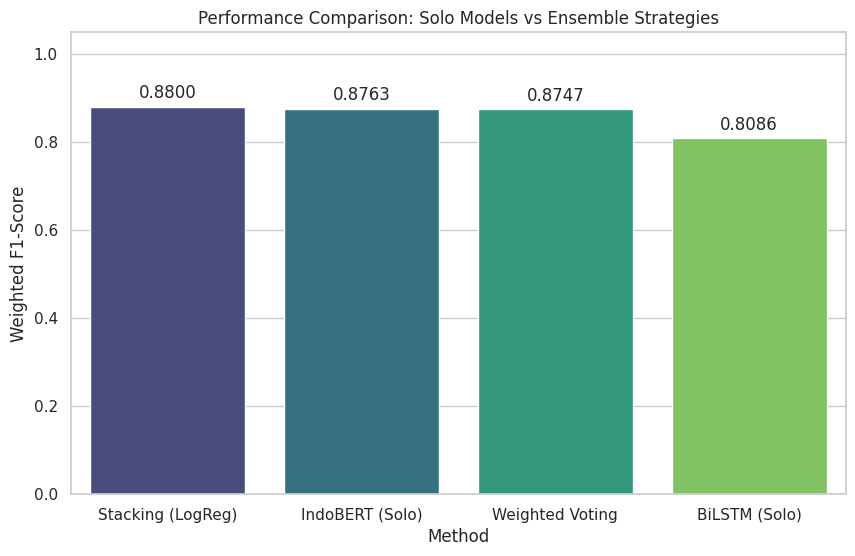

In [82]:
# Bar Chart Comparison
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Method', y='Weighted F1-Score', data=results_df, palette='viridis')
plt.ylim(0, 1.05)
plt.title('Performance Comparison: Solo Models vs Ensemble Strategies')
plt.ylabel('Weighted F1-Score')

# Add values on top of bars
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.4f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 10),
                     textcoords = 'offset points')
plt.show()